In [38]:
#%pip install python-docx
#%pip install contractions

In [101]:
import numpy as np
import pandas as pd
import sys,os
import csv
import string
import matplotlib.pyplot as plt
from docx import Document

import contractions
import nltk
#nltk.download("punkt")
#nltk.download("punkt_tab")
from nltk.tokenize import word_tokenize
#nltk.download("stopwords")
from nltk.corpus import stopwords
#nltk.download("wordnet")
from nltk.stem import WordNetLemmatizer

from nltk import pos_tag
#nltk.download('averaged_perceptron_tagger_eng')
from collections import Counter

In [102]:
# dirs
data_dir = './data/'

# Define subjects
participants = [49, 58, 95, 115, 127, 181, 186, 190, 191, 200, 201] + list(range(206, 238)) + list(range(239, 254))

# load group number of participants
GroupIndex = pd.read_csv("Narratives participants.csv")

# split
GroupIndex[['GroupNumber', 'TaskOrder']] = GroupIndex['Notes'].str.split(',', n=1, expand=True)

GroupIndex['GroupNumber'] = GroupIndex['GroupNumber'].str.strip()
GroupIndex['TaskOrder'] = GroupIndex['TaskOrder'].str.strip()

In [112]:
processedTextData = pd.DataFrame(columns=['participant','word_count_noStop_noFiller', 'sentence_count',
                                          'CC','CD','DT','EX','FW','IN','JJ','JJR','JJS','LS',
                                          'MD','NN','NNS','NNP','NNPS','PDT','POS','PRP','PRP$','RB',
                                          'RBR','RBS','RP','SYM','TO','UH','VB','VBD','VBG','VBN',
                                          'VBP','VBZ','WDT','WP','WP$','WRB',
                                          'nouns','verbs','adjectives','adverbs','pronouns',
                                          'conjunctions','prepositions','interjections','articles',
                                          'nouns_to_verbs_ratio','content_words_prop','function_words_prop','pronouns_to_nouns_ratio',
                                          'temporal_connectives_count','causal_connectives_count','GroupNumber','TaskOrder'])

# existing tags? https://www.ling.upenn.edu/courses/Fall_2003/ling001/penn_treebank_pos.html
# 1.	CC	Coordinating conjunction
# 2.	CD	Cardinal number
# 3.	DT	Determiner
# 4.	EX	Existential there
# 5.	FW	Foreign word
# 6.	IN	Preposition or subordinating conjunction
# 7.	JJ	Adjective
# 8.	JJR	Adjective, comparative
# 9.	JJS	Adjective, superlative
# 10.	LS	List item marker
# 11.	MD	Modal
# 12.	NN	Noun, singular or mass
# 13.	NNS	Noun, plural
# 14.	NNP	Proper noun, singular
# 15.	NNPS	Proper noun, plural
# 16.	PDT	Predeterminer
# 17.	POS	Possessive ending
# 18.	PRP	Personal pronoun
# 19.	PRP$	Possessive pronoun
# 20.	RB	Adverb
# 21.	RBR	Adverb, comparative
# 22.	RBS	Adverb, superlative
# 23.	RP	Particle
# 24.	SYM	Symbol
# 25.	TO	to
# 26.	UH	Interjection
# 27.	VB	Verb, base form
# 28.	VBD	Verb, past tense
# 29.	VBG	Verb, gerund or present participle
# 30.	VBN	Verb, past participle
# 31.	VBP	Verb, non-3rd person singular present
# 32.	VBZ	Verb, 3rd person singular present
# 33.	WDT	Wh-determiner
# 34.	WP	Wh-pronoun
# 35.	WP$	Possessive wh-pronoun
# 36.	WRB	Wh-adverb

# Define connectives and fillers
TEMPORAL_CONNECTIVES = ['then', 'after', 'after that', 'first', 'next', 'finally', 'meanwhile']
CAUSAL_CONNECTIVES = ['because', 'so', 'therefore', 'as a result', 'thus']

for participant in participants:

    print('processing participant: ',participant)
    
    if participant == 219:
        print('no data')
    elif participant == 220:
        print('no data')
    elif participant == 242:
        print('no data')
    else:
        fname = "sub-%03d_transcript.docx" % participant
        doc = data_dir + fname
    
        data = Document(doc)
    
        # Extract text from each paragraph (to make sure all text from document is included)
        text = []
        for para in data.paragraphs:
            text.append(para.text)
        
        # Join paragraphs into a single string
        full_text = "\n".join(text)

        # count number of sentences
        sentences = nltk.sent_tokenize(full_text)
    
        text = full_text.lower()
    
        # Expand contractions 
        text = contractions.fix(text)
    
        # tokenize
        tokens = word_tokenize(text)

        # extract amount of nouns, verbs etc.
        # POS tagging
        pos_tags = pos_tag(tokens)
    
        # Count POS
        pos_counts = Counter(tag for word, tag in pos_tags)

        # Initialize row dictionary with zeros for all columns
        row = {col: 0 for col in processedTextData.columns}
        
        # Update POS counts in the row dictionary
        for tag, count in pos_counts.items():
            if tag in row:  # only update if the tag exists
                row[tag] = count

        # Map POS tags to broader categories
        categories = {
            'nouns': ['NN', 'NNS', 'NNP', 'NNPS'],
            'verbs': ['VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ'],
            'adjectives': ['JJ', 'JJR', 'JJS'],
            'adverbs': ['RB', 'RBR', 'RBS'],
            'pronouns': ['PRP', 'PRP$', 'WP', 'WP$'],
            'conjunctions': ['CC'],
            'prepositions': ['IN'],
            'interjections': ['UH'],
            'articles': ['DT']
        }
        
        # Compute category counts
        cat_counts = {cat: sum(pos_counts[tag] for tag in tags if tag in pos_counts) 
                      for cat, tags in categories.items()}
        
        # Compute proportions
        cat_props = {cat: count / len(tokens) if len(tokens) > 0 else 0 
                     for cat, count in cat_counts.items()}
        
        # Lexical diversity
        lexical_diversity = len(set(tokens)) / len(tokens) if len(tokens) > 0 else 0

        # add all categories proportions to the dataframe
        row['nouns'] = cat_props['nouns']
        row['verbs'] = cat_props['verbs']
        row['adjectives'] = cat_props['adjectives']
        row['adverbs'] = cat_props['adverbs']
        row['pronouns'] = cat_props['pronouns']
        row['conjunctions'] = cat_props['conjunctions']
        row['prepositions'] = cat_props['prepositions']
        row['interjections'] = cat_props['interjections']
        row['articles'] = cat_props['articles']
        
        # Narrative metrics
        row['nouns_to_verbs_ratio'] = cat_props['nouns']/cat_props['verbs'] if cat_props['verbs']>0 else 0
        row['content_words_prop'] = cat_props['nouns'] + cat_props['verbs'] + cat_props['adjectives'] + cat_props['adverbs']
        row['function_words_prop'] = cat_props['pronouns'] + cat_props['conjunctions'] + cat_props['prepositions'] + cat_props['articles']
        row['pronouns_to_nouns_ratio'] = cat_props['pronouns']/cat_props['nouns'] if cat_props['nouns']>0 else 0
    
        # Connective counts
        row['temporal_connectives_count'] = sum(tokens.count(c) for c in TEMPORAL_CONNECTIVES)
        row['causal_connectives_count'] = sum(tokens.count(c) for c in CAUSAL_CONNECTIVES)
        
        ## to count total number of words without including stopwords and filler words
        # Remove punctuation & stopwords
        stop_words = set(stopwords.words("english"))
        tokens = [t for t in tokens if t not in string.punctuation and t not in stop_words]
    
        filler_words = {"um", "uh", "erm", "mm", "ah", "like", "you know"}
        tokens = [t for t in tokens if t not in filler_words]
    
        # Lemmatize
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
        row['word_count_noStop_noFiller'] = len(tokens)
        row['sentence_count'] = len(sentences)

        # add group info
        bids_id = "sub-%03d" % participant

        groupNumber = GroupIndex.loc[GroupIndex['BIDS ID'] == bids_id, 'GroupNumber'].values[0]
        taskOrder = GroupIndex.loc[GroupIndex['BIDS ID'] == bids_id, 'TaskOrder'].values[0]

        row['GroupNumber'] = groupNumber
        row['TaskOrder'] = taskOrder

        row['participant'] = participant
        
        # Append row to DataFrame
        # Convert row dict to DataFrame
        row_df = pd.DataFrame([row])
        
        # Concatenate to main DataFrame
        processedTextData = pd.concat([processedTextData, row_df], ignore_index=True)

# Save DataFrame to CSV
processedTextData.to_csv('processedTextData.csv', index=False)
            

processing participant:  49
processing participant:  58
processing participant:  95
processing participant:  115
processing participant:  127
processing participant:  181
processing participant:  186
processing participant:  190
processing participant:  191
processing participant:  200
processing participant:  201
processing participant:  206
processing participant:  207
processing participant:  208
processing participant:  209
processing participant:  210
processing participant:  211
processing participant:  212


/var/folders/2b/y7vqbp2s3slchmzyrsz69p1m0000gn/T/ipykernel_4276/2107668107.py:179: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  processedTextData = pd.concat([processedTextData, row_df], ignore_index=True)


processing participant:  213
processing participant:  214
processing participant:  215
processing participant:  216
processing participant:  217
processing participant:  218
processing participant:  219
no data
processing participant:  220
no data
processing participant:  221
processing participant:  222
processing participant:  223
processing participant:  224
processing participant:  225
processing participant:  226
processing participant:  227
processing participant:  228
processing participant:  229
processing participant:  230
processing participant:  231
processing participant:  232
processing participant:  233
processing participant:  234
processing participant:  235
processing participant:  236
processing participant:  237
processing participant:  239
processing participant:  240
processing participant:  241
processing participant:  242
no data
processing participant:  243
processing participant:  244
processing participant:  245
processing participant:  246
processing particip

## quick look at differences across groups

In [114]:
group1_data = processedTextData[processedTextData['GroupNumber'] == 'group1']
group2_data = processedTextData[processedTextData['GroupNumber'] == 'group2']
group3_data = processedTextData[processedTextData['GroupNumber'] == 'group3']

In [116]:
# Select columns from 'CC' to 'WRB' (inclusive)
group1_tags = group1_data.loc[:, 'CC':'WRB']
group2_tags = group2_data.loc[:, 'CC':'WRB']
group3_tags = group3_data.loc[:, 'CC':'WRB']

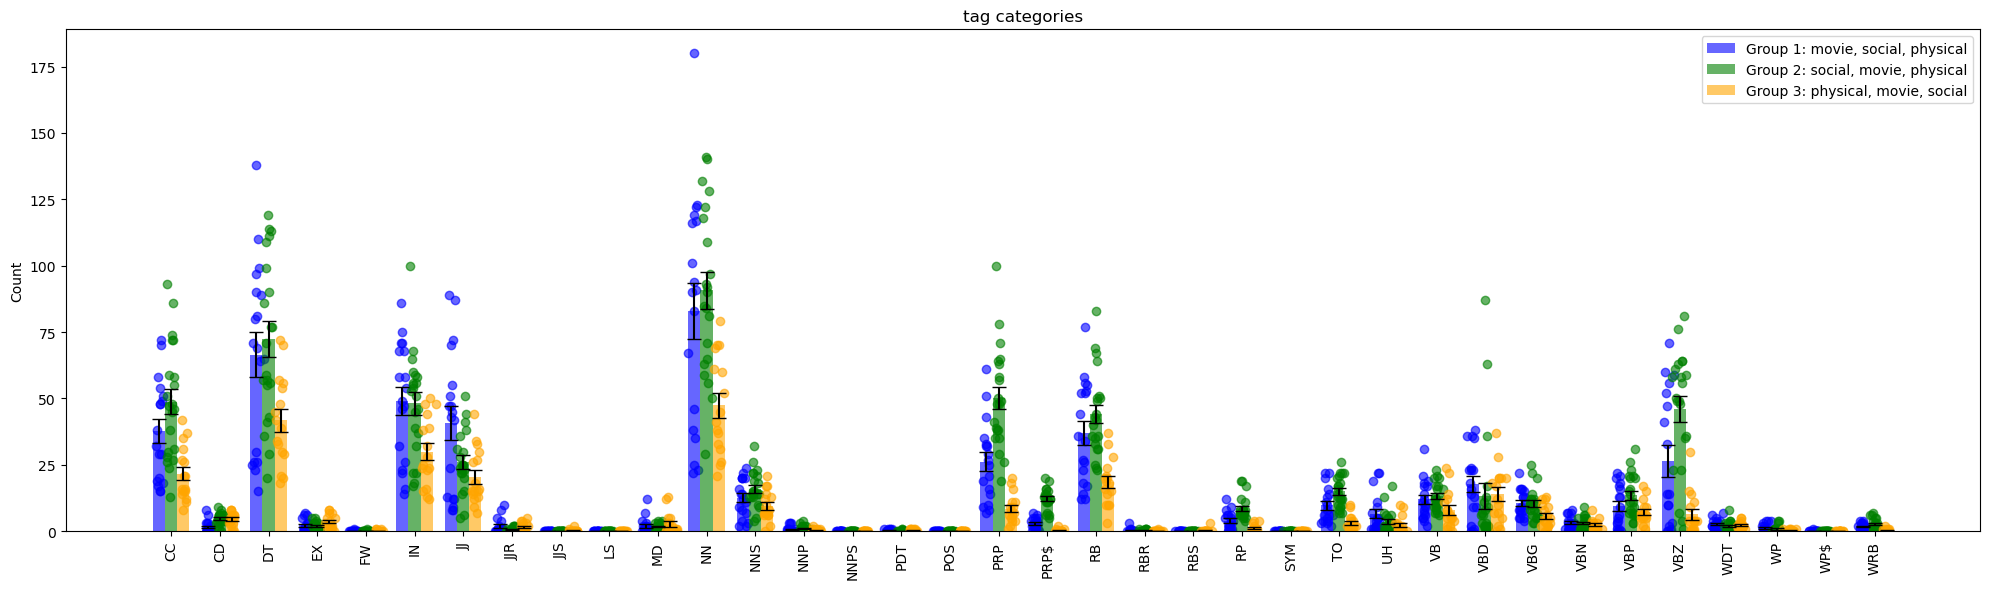

In [165]:
# Ensure all data is numeric
group1_numeric = group1_tags.apply(pd.to_numeric, errors='coerce')
group2_numeric = group2_tags.apply(pd.to_numeric, errors='coerce')
group3_numeric = group3_tags.apply(pd.to_numeric, errors='coerce')

groups = [group1_numeric, group2_numeric, group3_numeric]
group_labels = ['Group 1: movie, shapessocial, shapesphysical', 'Group 2: shapessocial, movie, shapesphysical', 'Group 3: shapesphysical, movie, shapessocial']
colors = ['blue', 'green', 'orange']

# Number of columns
n_cols = group1_numeric.shape[1]
x = np.arange(n_cols)  # x positions for columns
width = 0.25  # width of each bar

plt.figure(figsize=(20,6))

for i, (group, label, color) in enumerate(zip(groups, group_labels, colors)):
    # Compute mean and SEM
    mean_vals = group.mean()
    sem_vals = group.sem()
    
    # Position for this group's bars
    x_pos = x + i*width - width  # center the grouped bars
    
    # Bar plot with SEM
    plt.bar(x_pos, mean_vals, width=width, color=color, alpha=0.6, yerr=sem_vals, capsize=5, label=label)
    
    # Overlay individual participant dots with jitter
    for j in range(group.shape[0]):
        jitter = np.random.normal(0, width/5, size=group.shape[1])
        plt.scatter(x_pos + jitter, group.iloc[j, :], color=color, alpha=0.6)

# Set x-ticks to the column names (centered)
plt.xticks(ticks=x, labels=group1_numeric.columns, rotation=90)
plt.ylabel('Count')
plt.title('tag categories')
plt.legend()
plt.tight_layout()

plt.savefig('plot1_recallData.png')

plt.show()

In [155]:
# Select columns from categories
group1_tags2 = group1_data.loc[:, 'nouns':'articles']
group2_tags2 = group2_data.loc[:, 'nouns':'articles']
group3_tags2 = group3_data.loc[:, 'nouns':'articles']

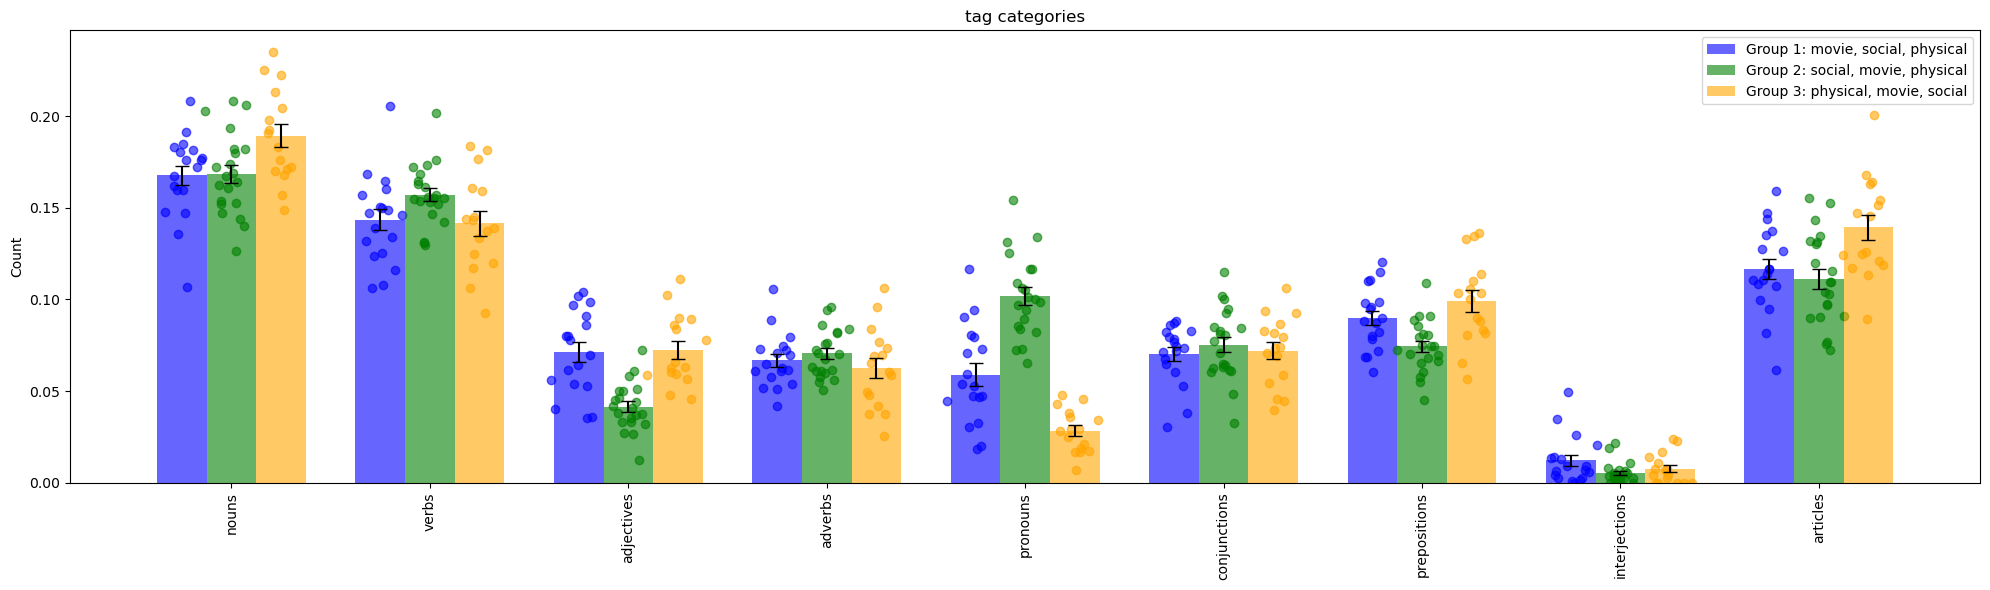

In [163]:
# Ensure all data is numeric
group1_numeric2 = group1_tags2.apply(pd.to_numeric, errors='coerce')
group2_numeric2 = group2_tags2.apply(pd.to_numeric, errors='coerce')
group3_numeric2 = group3_tags2.apply(pd.to_numeric, errors='coerce')

groups = [group1_numeric2, group2_numeric2, group3_numeric2]
group_labels = ['Group 1: movie, shapessocial, shapesphysical', 'Group 2: shapessocial, movie, shapesphysical', 'Group 3: shapesphysical, movie, shapessocial']
colors = ['blue', 'green', 'orange']

# Number of columns
n_cols = group1_numeric2.shape[1]
x = np.arange(n_cols)  # x positions for columns
width = 0.25  # width of each bar

plt.figure(figsize=(20,6))

for i, (group, label, color) in enumerate(zip(groups, group_labels, colors)):
    # Compute mean and SEM
    mean_vals = group.mean()
    sem_vals = group.sem()
    
    # Position for this group's bars
    x_pos = x + i*width - width  # center the grouped bars
    
    # Bar plot with SEM
    plt.bar(x_pos, mean_vals, width=width, color=color, alpha=0.6, yerr=sem_vals, capsize=5, label=label)
    
    # Overlay individual participant dots with jitter
    for j in range(group.shape[0]):
        jitter = np.random.normal(0, width/5, size=group.shape[1])
        plt.scatter(x_pos + jitter, group.iloc[j, :], color=color, alpha=0.6)

# Set x-ticks to the column names (centered)
plt.xticks(ticks=x, labels=group1_numeric2.columns, rotation=90)
plt.ylabel('Count')
plt.title('tag categories')
plt.legend()
plt.tight_layout()

plt.savefig('plot2_recallData.png')

plt.show()

In [157]:
# Select columns from narrative metrics 
group1_tags3 = group1_data.loc[:, 'nouns_to_verbs_ratio':'pronouns_to_nouns_ratio']
group2_tags3 = group2_data.loc[:, 'nouns_to_verbs_ratio':'pronouns_to_nouns_ratio']
group3_tags3 = group3_data.loc[:, 'nouns_to_verbs_ratio':'pronouns_to_nouns_ratio']

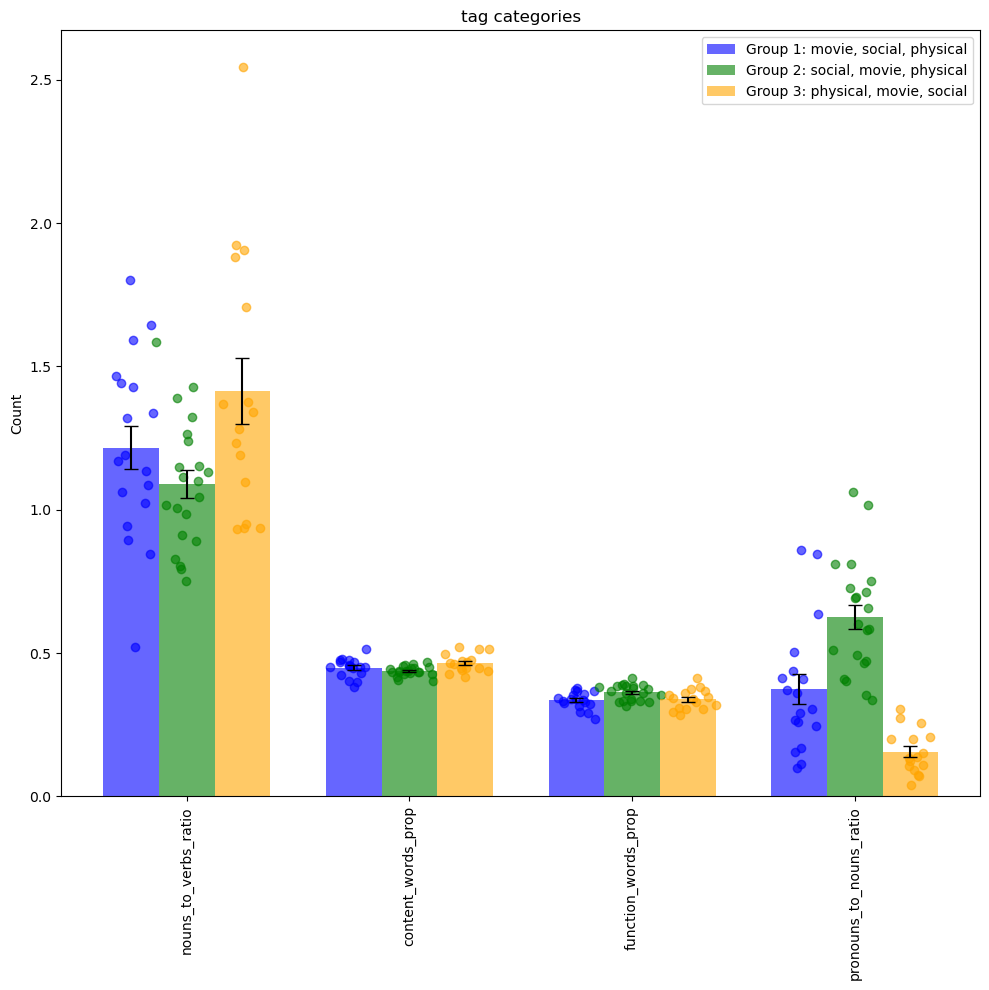

In [161]:
# Ensure all data is numeric
group1_numeric3 = group1_tags3.apply(pd.to_numeric, errors='coerce')
group2_numeric3 = group2_tags3.apply(pd.to_numeric, errors='coerce')
group3_numeric3 = group3_tags3.apply(pd.to_numeric, errors='coerce')

groups = [group1_numeric3, group2_numeric3, group3_numeric3]
group_labels = ['Group 1: movie, shapessocial, shapesphysical', 'Group 2: shapessocial, movie, shapesphysical', 'Group 3: shapesphysical, movie, shapessocial']
colors = ['blue', 'green', 'orange']

# Number of columns
n_cols = group1_numeric3.shape[1]
x = np.arange(n_cols)  # x positions for columns
width = 0.25  # width of each bar

plt.figure(figsize=(10,10))

for i, (group, label, color) in enumerate(zip(groups, group_labels, colors)):
    # Compute mean and SEM
    mean_vals = group.mean()
    sem_vals = group.sem()
    
    # Position for this group's bars
    x_pos = x + i*width - width  # center the grouped bars
    
    # Bar plot with SEM
    plt.bar(x_pos, mean_vals, width=width, color=color, alpha=0.6, yerr=sem_vals, capsize=5, label=label)
    
    # Overlay individual participant dots with jitter
    for j in range(group.shape[0]):
        jitter = np.random.normal(0, width/5, size=group.shape[1])
        plt.scatter(x_pos + jitter, group.iloc[j, :], color=color, alpha=0.6)

# Set x-ticks to the column names (centered)
plt.xticks(ticks=x, labels=group1_numeric3.columns, rotation=90)
plt.ylabel('Count')
plt.title('tag categories')
plt.legend()
plt.tight_layout()

plt.savefig('plot3_recallData.png')

plt.show()

In [159]:
# Select columns from narrative metrics 
group1_tags4 = group1_data.loc[:, 'temporal_connectives_count':'causal_connectives_count']
group2_tags4 = group2_data.loc[:, 'temporal_connectives_count':'causal_connectives_count']
group3_tags4 = group3_data.loc[:, 'temporal_connectives_count':'causal_connectives_count']


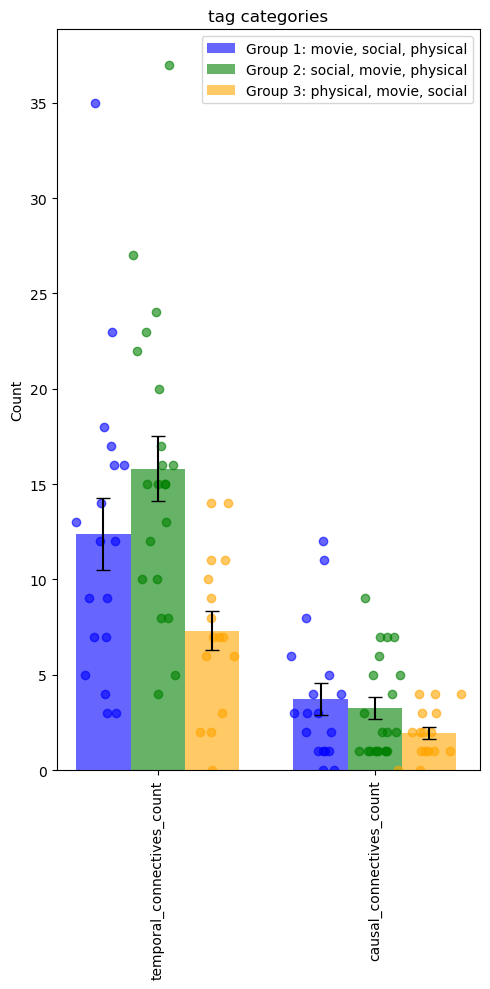

In [162]:
# Ensure all data is numeric
group1_numeric4 = group1_tags4.apply(pd.to_numeric, errors='coerce')
group2_numeric4 = group2_tags4.apply(pd.to_numeric, errors='coerce')
group3_numeric4 = group3_tags4.apply(pd.to_numeric, errors='coerce')

groups = [group1_numeric4, group2_numeric4, group3_numeric4]
group_labels = ['Group 1: movie, shapessocial, shapesphysical', 'Group 2: shapessocial, movie, shapesphysical', 'Group 3: shapesphysical, movie, shapessocial']
colors = ['blue', 'green', 'orange']

# Number of columns
n_cols = group1_numeric4.shape[1]
x = np.arange(n_cols)  # x positions for columns
width = 0.25  # width of each bar

plt.figure(figsize=(5,10))

for i, (group, label, color) in enumerate(zip(groups, group_labels, colors)):
    # Compute mean and SEM
    mean_vals = group.mean()
    sem_vals = group.sem()
    
    # Position for this group's bars
    x_pos = x + i*width - width  # center the grouped bars
    
    # Bar plot with SEM
    plt.bar(x_pos, mean_vals, width=width, color=color, alpha=0.6, yerr=sem_vals, capsize=5, label=label)
    
    # Overlay individual participant dots with jitter
    for j in range(group.shape[0]):
        jitter = np.random.normal(0, width/5, size=group.shape[1])
        plt.scatter(x_pos + jitter, group.iloc[j, :], color=color, alpha=0.6)

# Set x-ticks to the column names (centered)
plt.xticks(ticks=x, labels=group1_numeric4.columns, rotation=90)
plt.ylabel('Count')
plt.title('tag categories')
plt.legend()
plt.tight_layout()


plt.savefig('plot4_recallData.png')

plt.show()

In [166]:
# Select columns from word count and sentence count
group1_tags5 = group1_data.loc[:, 'word_count_noStop_noFiller':'sentence_count']
group2_tags5 = group2_data.loc[:, 'word_count_noStop_noFiller':'sentence_count']
group3_tags5 = group3_data.loc[:, 'word_count_noStop_noFiller':'sentence_count']


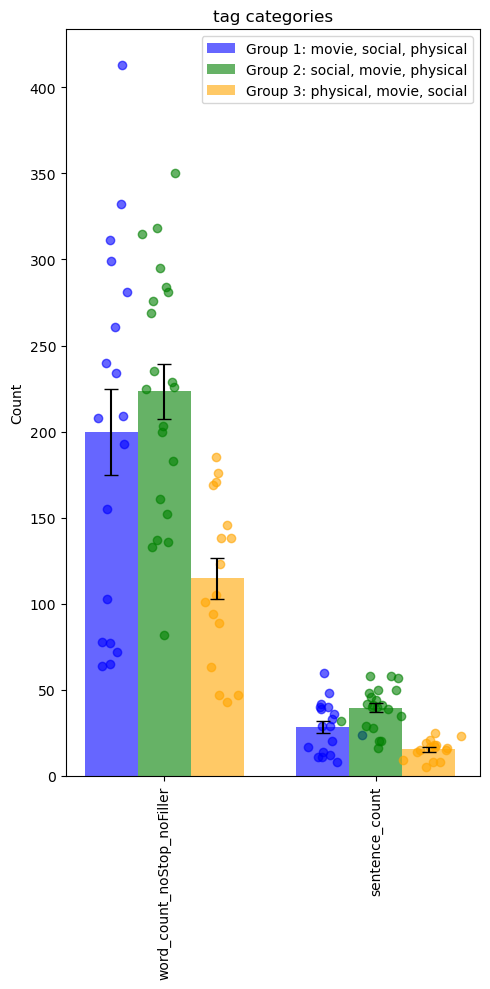

In [167]:
# Ensure all data is numeric
group1_numeric5 = group1_tags5.apply(pd.to_numeric, errors='coerce')
group2_numeric5 = group2_tags5.apply(pd.to_numeric, errors='coerce')
group3_numeric5 = group3_tags5.apply(pd.to_numeric, errors='coerce')

groups = [group1_numeric5, group2_numeric5, group3_numeric5]
group_labels = ['Group 1: movie, shapessocial, shapesphysical', 'Group 2: shapessocial, movie, shapesphysical', 'Group 3: shapesphysical, movie, shapessocial']
colors = ['blue', 'green', 'orange']

# Number of columns
n_cols = group1_numeric5.shape[1]
x = np.arange(n_cols)  # x positions for columns
width = 0.25  # width of each bar

plt.figure(figsize=(5,10))

for i, (group, label, color) in enumerate(zip(groups, group_labels, colors)):
    # Compute mean and SEM
    mean_vals = group.mean()
    sem_vals = group.sem()
    
    # Position for this group's bars
    x_pos = x + i*width - width  # center the grouped bars
    
    # Bar plot with SEM
    plt.bar(x_pos, mean_vals, width=width, color=color, alpha=0.6, yerr=sem_vals, capsize=5, label=label)
    
    # Overlay individual participant dots with jitter
    for j in range(group.shape[0]):
        jitter = np.random.normal(0, width/5, size=group.shape[1])
        plt.scatter(x_pos + jitter, group.iloc[j, :], color=color, alpha=0.6)

# Set x-ticks to the column names (centered)
plt.xticks(ticks=x, labels=group1_numeric5.columns, rotation=90)
plt.ylabel('Count')
plt.title('tag categories')
plt.legend()
plt.tight_layout()


plt.savefig('plot5_recallData.png')

plt.show()